# Environmental controls of measured tilt
Environmental PV-gradient magnitude, planetary beta, latitude, bathymetry, gradient coherence and existing background shear. PV magnitudes use **log10** for display and comparison. The standard environmental gradient excludes the internal eddy-vorticity-gradient contribution. Core stratification is analysed in the companion eddy-properties notebook, not relabelled as background stratification.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
HERE=Path.cwd().resolve()
ANALYSIS=next((p for p in (HERE,*HERE.parents) if (p/'seacofs_tilt_tools.py').exists()),None)
if ANALYSIS is None: raise FileNotFoundError('Launch inside seacofs_eddy_tilt_analysis')
WORK=ANALYSIS/'eddy_env_tilt_controls'
for p in (ANALYSIS,WORK,ANALYSIS/'tilt_mechanisms'):
    if str(p) not in sys.path: sys.path.insert(0,str(p))
import seacofs_tilt_tools as tilt
import control_tools as ctl
import mechanism_tools as mech
N_BOOT=300
MIN_EDDIES_PER_BIN=10
MAX_DEPTH_M=1000
TARGET_DEPTHS=[0,100,200,500,1000]
DEPTH_TOLERANCE_M=65
MIN_N2_COVERAGE=.8
SAVE_RESULTS=True
paths=tilt.Paths()
OUTPUT_ROOT=Path('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset_modular/eddy_env_tilt_controls')
N2_CACHE=mech.DEFAULT_N2_CACHE_PATH
VV_CACHE=Path('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset_modular/vertical_velocity_climatology/core_vertical_velocity_upper_1000m.parquet')
VV_FRACTION=1.5
MIN_VV_CELLS=8
MIN_VV_COVERAGE=.7
results={}
inputs=[paths.eddies,paths.tilt,paths.vert,paths.grid,paths.z_r,WORK/'control_tools.py']

In [2]:
grid=tilt.load_grid(paths.grid,paths.z_r)
raw,_=tilt.load_tilt_tables(paths,add_regions=True,grid=grid)
surface=ctl.prepare_surface(raw,grid)
vertical=ctl.prepare_profiles(tilt.load_vert(paths),surface,MAX_DEPTH_M)
summary=ctl.profile_summaries(vertical)
surface=ctl.merge(surface,summary)
print('Surface rows:',len(surface),'Eddies:',surface.Eddy.nunique())
print('Rows with profiles:',surface.vertical_extent_m.notna().sum())
print('Measured TiltDis/TiltDir are loaded, never recomputed.')

Surface rows: 127426 Eddies: 2982
Rows with profiles: 120543
Measured TiltDis/TiltDir are loaded, never recomputed.


In [3]:
# vertical = tilt.load_vert(paths)
# from scipy.spatial.distance import pdist
# spread = (vertical.groupby(['Eddy','Day'])
#           .apply(lambda x: pdist(x[['xc','yc']].dropna()).max()
#                  if x[['xc','yc']].dropna().shape[0] > 1 else np.nan)
#           .rename('TiltMaxSpread').reset_index())

# surface = surface.merge(spread, on=['Eddy','Day'], how='left')
# surface['TiltDis'] = surface['TiltMaxSpread']

## Reading the plots and statistics
Red = AE, blue = CE. Curves are **eddy-day medians** in shared quantile bins; shading is the IQR, not uncertainty. Vertical bars are pointwise 95% intervals obtained by resampling whole contributing eddies in each bin. Bins with fewer than `MIN_EDDIES_PER_BIN` distinct eddies are omitted. No bin, including the upper endpoint, is discarded.

An equal-eddy sensitivity computes correlations between per-eddy median properties and median tilt; its intervals resample eddies. These are between-eddy associations. The adjusted models use inverse-observation-count weights within each eddy and eddy-clustered standard errors, separately by polarity, with one focal property at a time. They control radius, vertical extent, latitude, region and season where available; a focal control is removed from its own control list. Latitude is omitted for beta because they encode the same geographic gradient. Estimates are changes in **log(1 + outcome)** per SD of the predictor. BH q-values cover the tested predictor/polarity family in each table. These exploratory models do not establish causation or remove all spatial dependence.

Profile depth coverage and the existing smoothed tilt estimator affect interpretation. Extrema grow sensitive to sampled depth range and sampling density. Compare the matched-depth analysis and common-depth profile summaries before interpreting full-profile maxima. `TiltDis/Rc` also shares radius with radius-related predictors; it is a sensitivity outcome, not independent confirmation.

## Existing surface PV cache
Preserve the established surface Gaussian footprint (`frac=1`, nonlinear averaging, signed largest-|vorticity| in the upper 1000 m). Cache validation checks these settings. The cache loader returns a saved table: only environmental fields are merged into the freshly loaded surface observations, preventing saved tilt/property values from replacing current data. Missing cache files stop with instructions; this notebook does not overwrite the shared cache.

Planetary beta is `df/dy` (m⁻¹ s⁻¹); the planetary PV-gradient contribution is beta/h (m⁻² s⁻¹). Logged gradients are log10 of numerical magnitudes in m⁻² s⁻¹. Nonpositive magnitudes remain missing. Latitude and beta are related geographic descriptions, not independent mechanisms. Coherence distinguishes weak mean vectors from cancellation among strong local gradients.

,metric,Cyc,eddy_days,eddies,missing,status
0,log10_PV_grad_mag,AE,51167,1416,13785,available
1,log10_PV_grad_mag,CE,50489,1530,11985,available
2,log10_PV_grad_plan_mag,AE,51167,1416,13785,available
3,log10_PV_grad_plan_mag,CE,50489,1530,11985,available
4,log10_PV_grad_topo_mag,AE,51167,1416,13785,available
5,log10_PV_grad_topo_mag,CE,50489,1530,11985,available
6,log10_topo_plan_ratio,AE,51167,1416,13785,available
7,log10_topo_plan_ratio,CE,50489,1530,11985,available
8,PV_grad_coherence,AE,51167,1416,13785,available
9,PV_grad_coherence,CE,50489,1530,11985,available


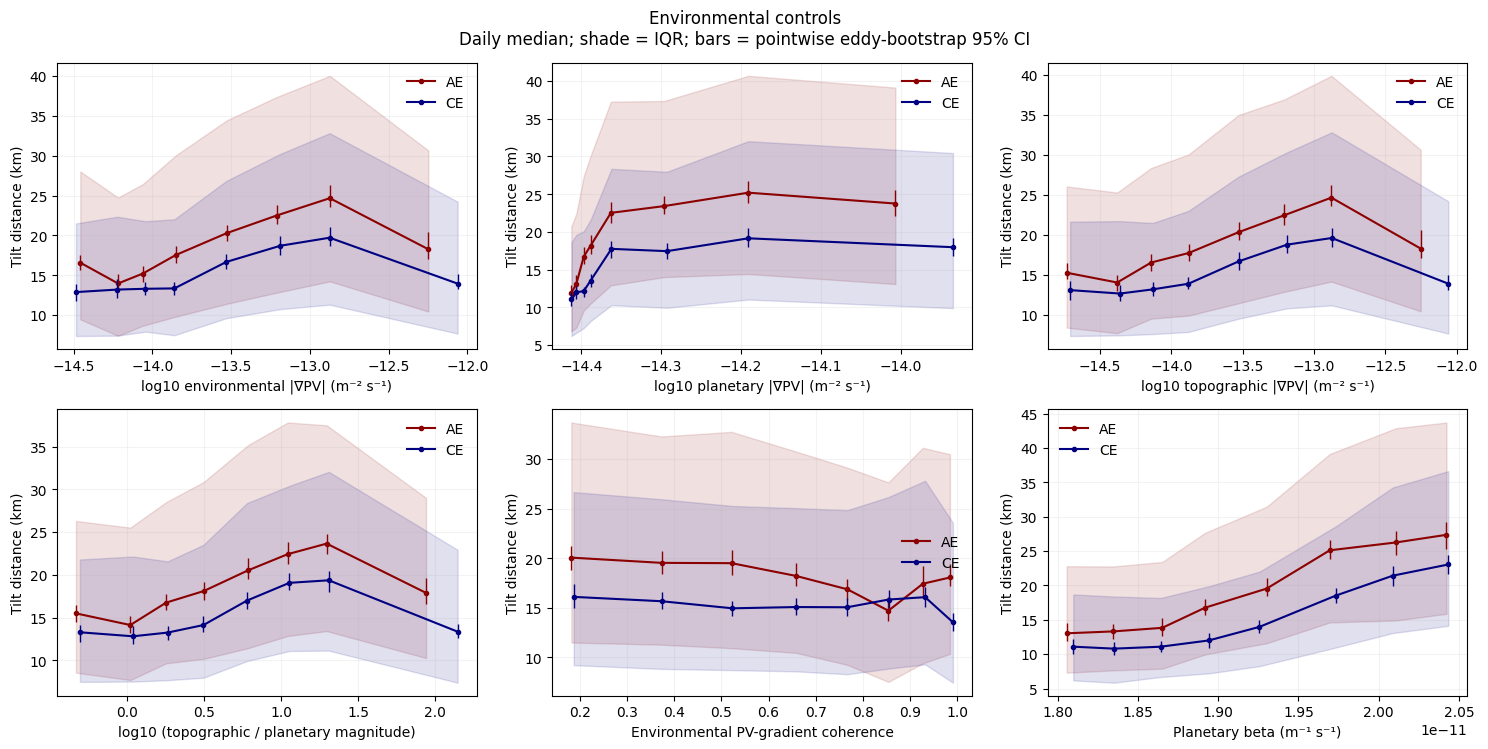

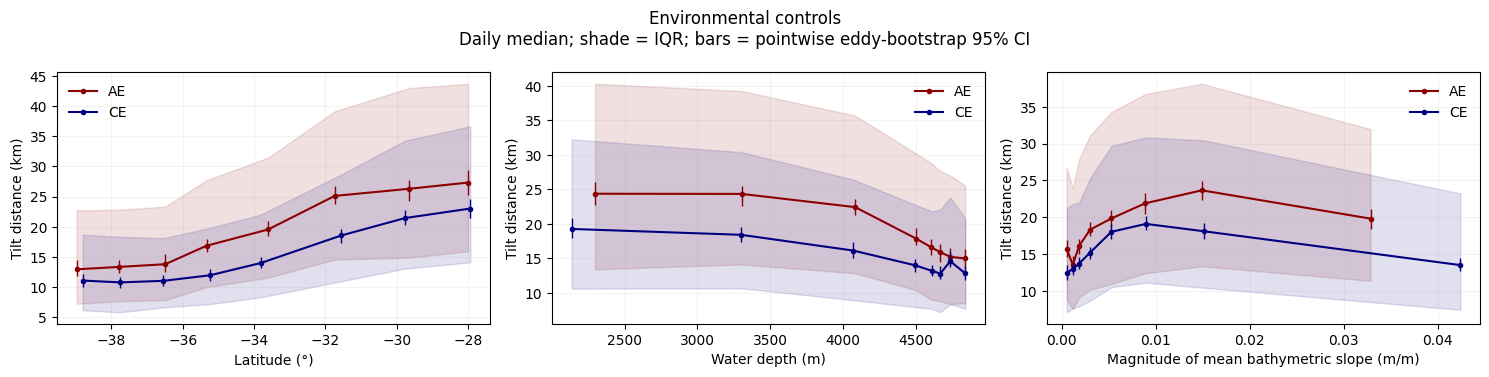

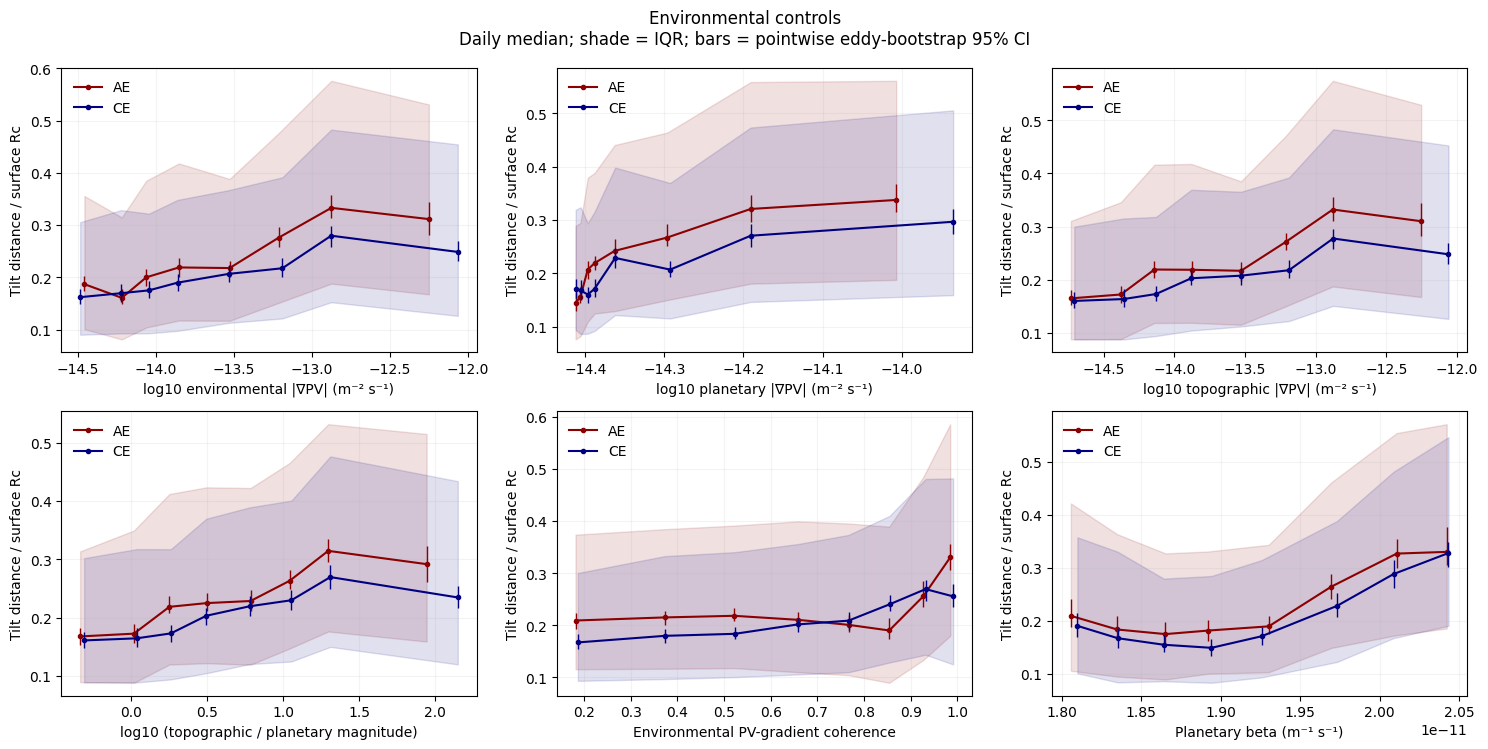

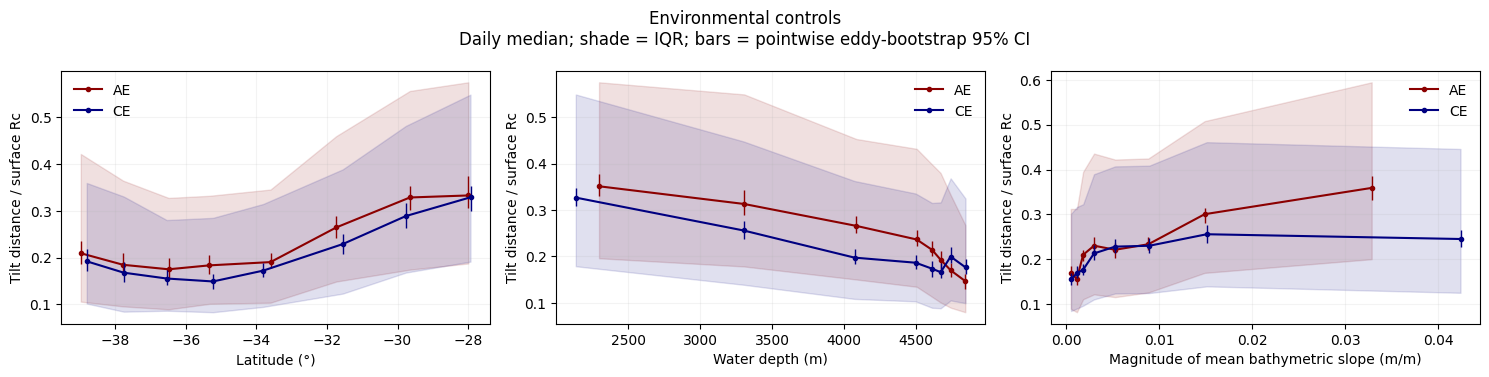

In [4]:
inputs.append(tilt.DEFAULT_SURFACE_PV_CACHE)
if not tilt.DEFAULT_SURFACE_PV_CACHE.exists():
    raise FileNotFoundError(f'Build the established surface PV cache first: {tilt.DEFAULT_SURFACE_PV_CACHE}; see surface_pv_esp_gaussian.')
pv=tilt.add_pv_gradient_terms(surface,grid,core_mean=True,frac=1.,surface_method='esp_gaussian',averaging='nonlinear',use_max_abs_w=True,max_depth_m=1000,use_cache=True)
environment=ctl.add_environment(surface,pv)
env_metrics=['log10_PV_grad_mag','log10_PV_grad_plan_mag','log10_PV_grad_topo_mag',
             'log10_topo_plan_ratio','PV_grad_coherence','beta','lat','h','slope']
results['environment_availability']=ctl.audit(environment,env_metrics)
display(results['environment_availability'])
for outcome in ['TiltDis','tilt_over_radius']:
    results['environment_bins_'+outcome]=ctl.panels(environment,env_metrics,y=outcome,n_boot=N_BOOT,min_eddies=MIN_EDDIES_PER_BIN,title='Environmental controls')

## Background shear: existing cache only
This retains the agreed shear-magnitude and tilt-direction comparison. It does not add propagation or along-/cross-shear mechanism extensions. The centred 91-day climatological **surface-minus-0–500 m mean velocity difference** is a bulk shear proxy in m/s, not a local derivative in s⁻¹. The absolute angle from the deep-to-shallow tilt direction spans 0–180°. Zero shear or zero tilt has undefined alignment.

No background stratification estimate is available in the core-N2 cache; core N2 remains in the other notebook.

,metric,Cyc,eddy_days,eddies,missing,status
0,shear_mag_ms,AE,51167,1416,13785,available
1,shear_mag_ms,CE,50489,1530,11985,available
2,shear_angle_deg,AE,51167,1416,13785,available
3,shear_angle_deg,CE,50489,1530,11985,available


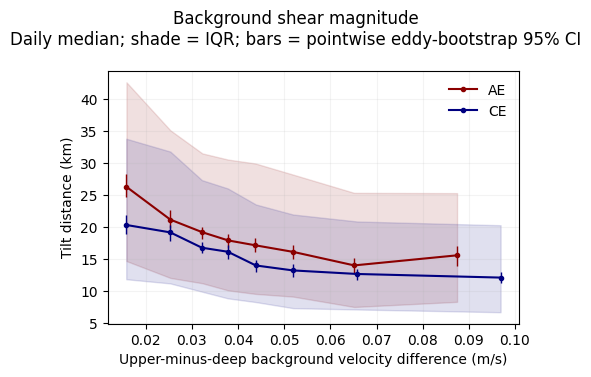

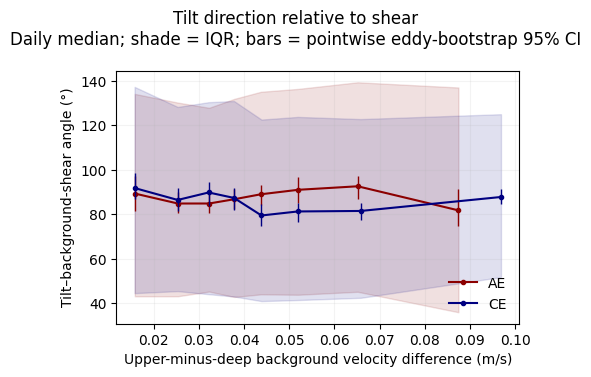

In [5]:
from beta_effect_background_flow.background_flow_tools import BackgroundConfig,load_background_cache
bg_config=BackgroundConfig()
inputs.append(bg_config.background_table_path)
if bg_config.background_table_path.exists():
    background=load_background_cache(bg_config)
    environment=ctl.add_shear(environment,background)
    env_metrics+=['shear_mag_ms']
    results['shear_availability']=ctl.audit(environment,['shear_mag_ms','shear_angle_deg'])
    display(results['shear_availability'])
    results['shear_magnitude_bins']=ctl.panels(environment,['shear_mag_ms'],n_boot=N_BOOT,min_eddies=MIN_EDDIES_PER_BIN,title='Background shear magnitude')
    results['shear_direction_bins']=ctl.panels(environment,['shear_mag_ms'],y='shear_angle_deg',n_boot=N_BOOT,min_eddies=MIN_EDDIES_PER_BIN,title='Tilt direction relative to shear')
else:
    print('SHEAR SECTION UNAVAILABLE:',bg_config.background_table_path)

## Regional and seasonal sensitivity
Repeat key relationships within each region and season; tables retain counts so sparse groups remain apparent. Seasonal names denote calendar quarters (DJF/MAM/JJA/SON). These comparisons test population composition, not independent new replications.

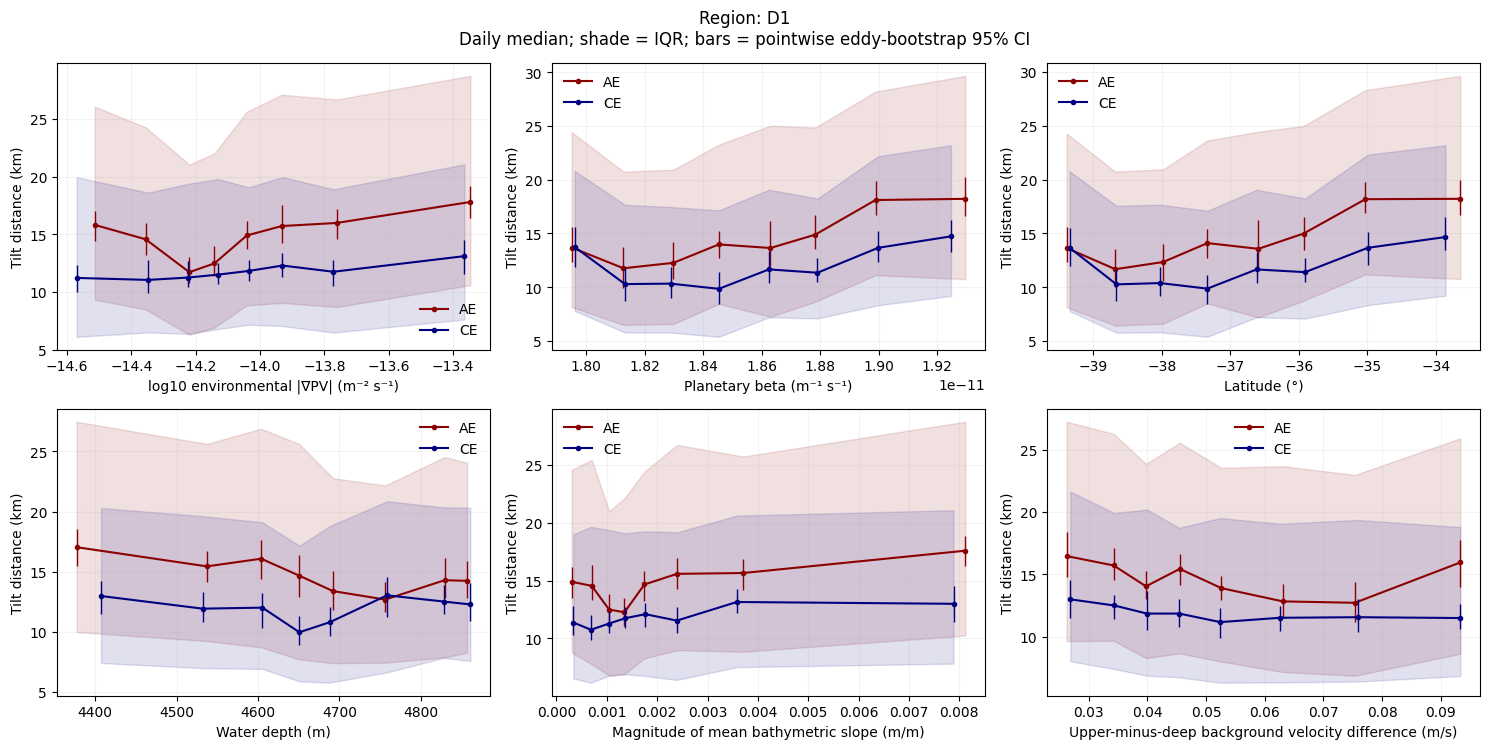

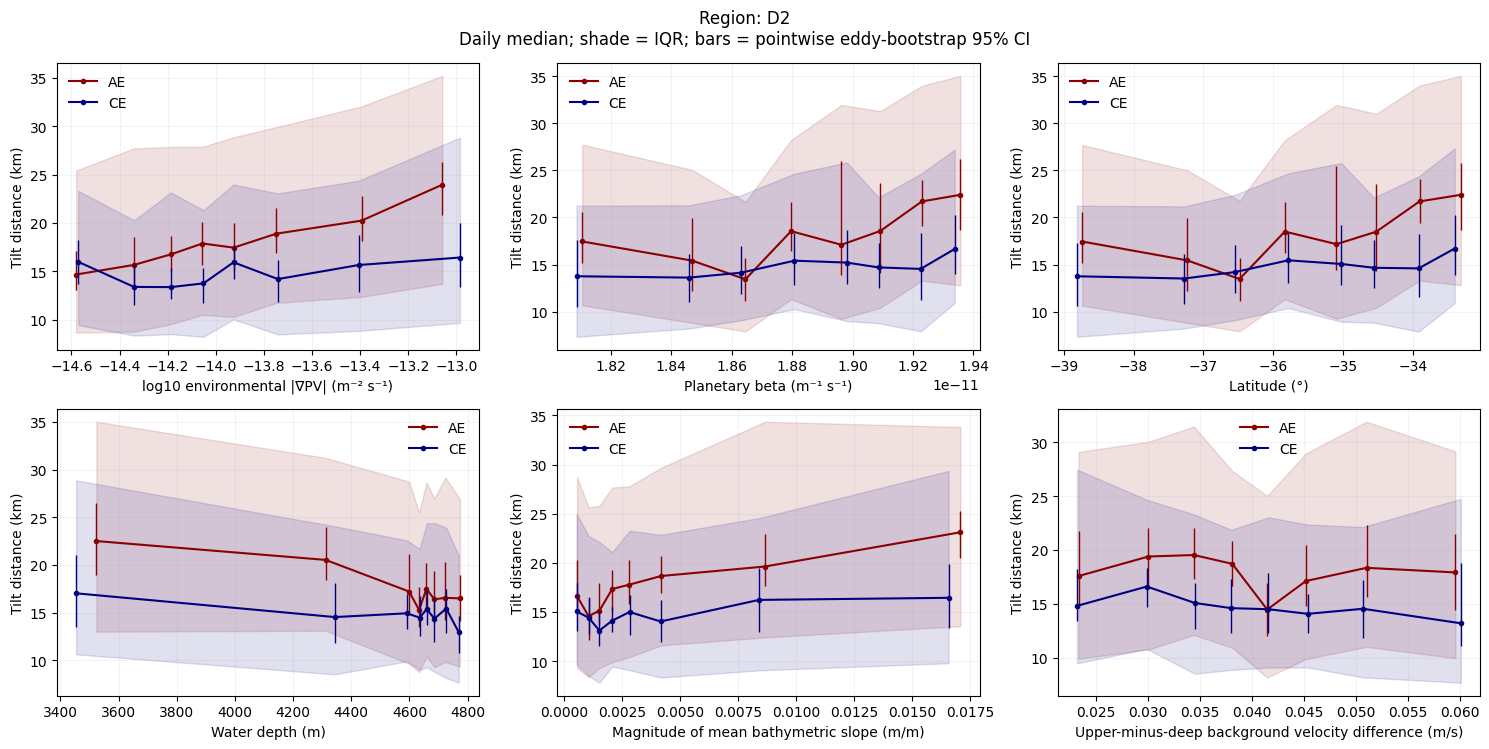

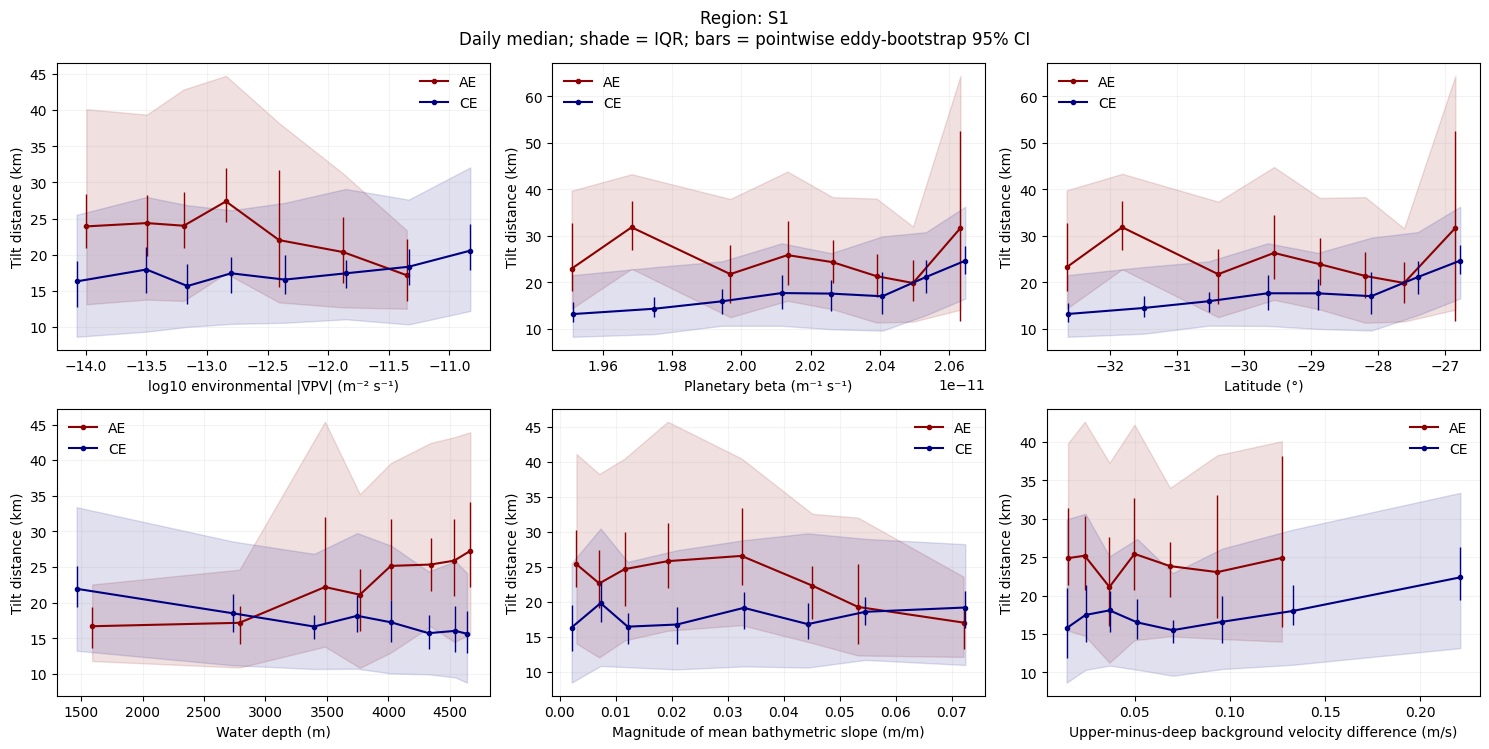

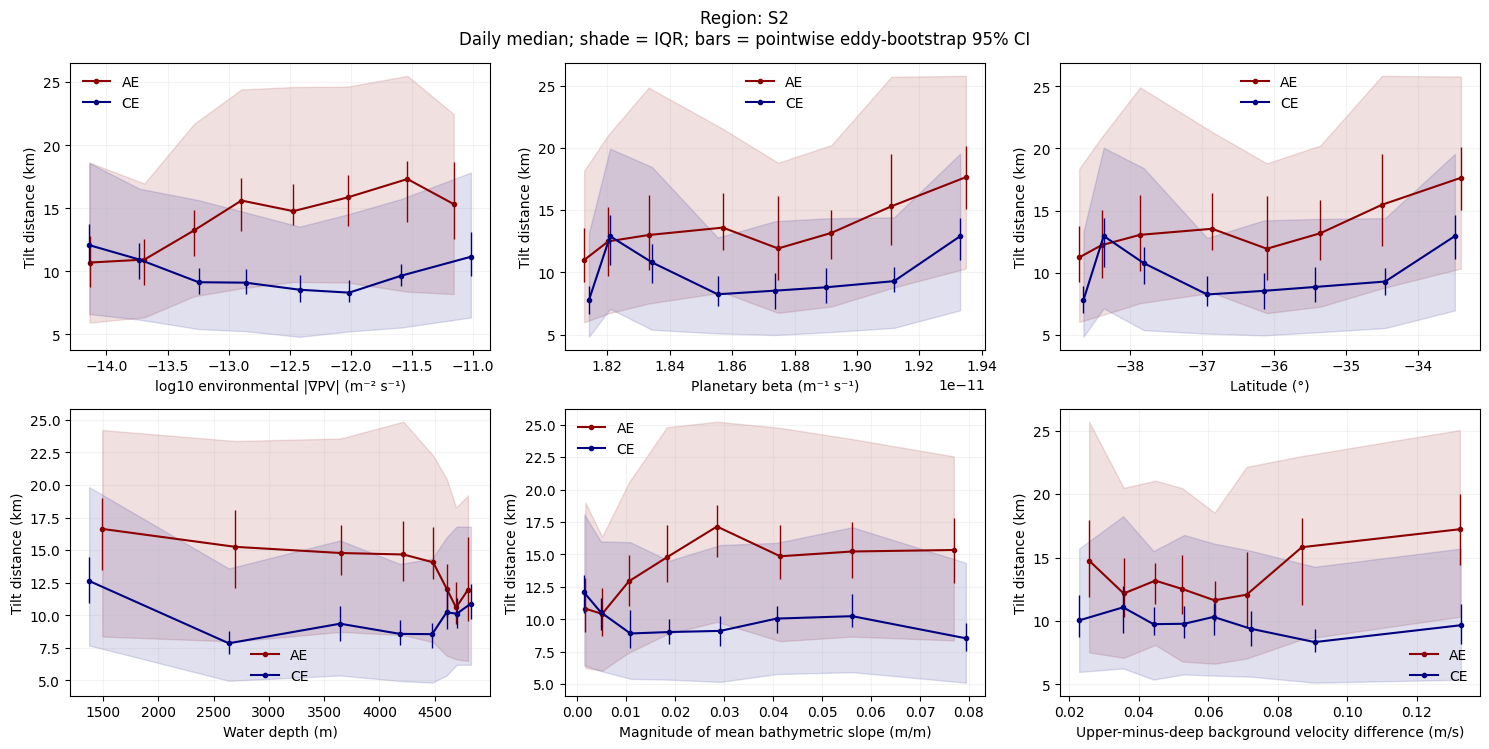

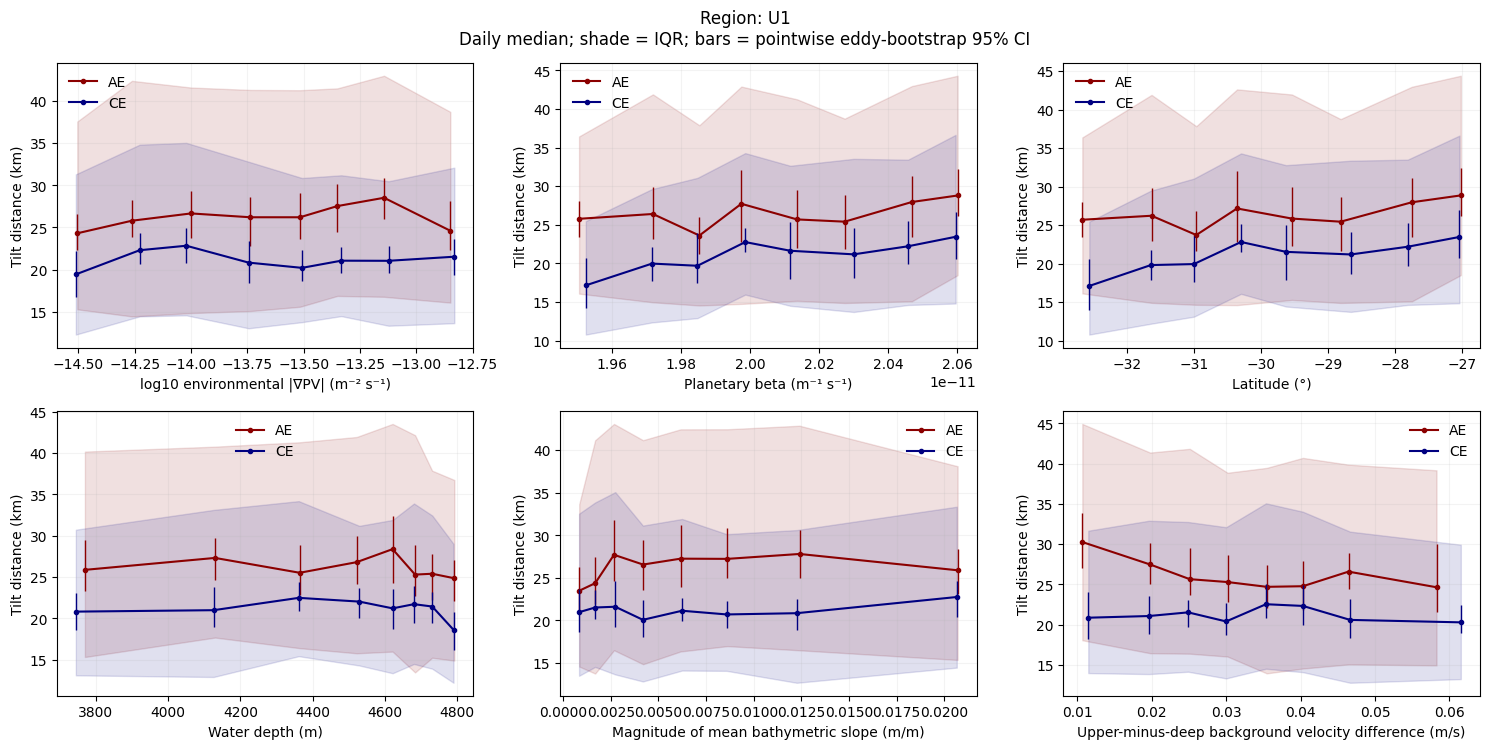

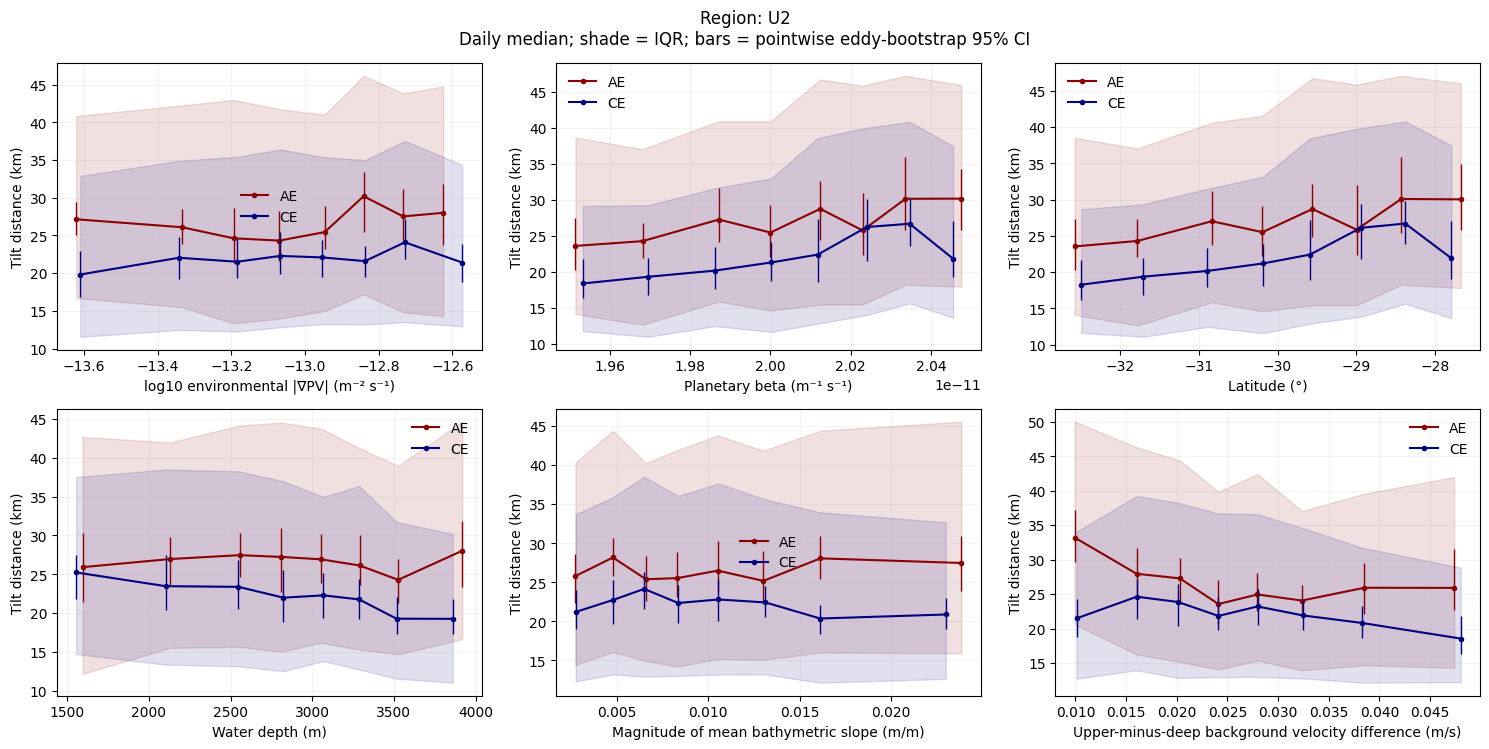

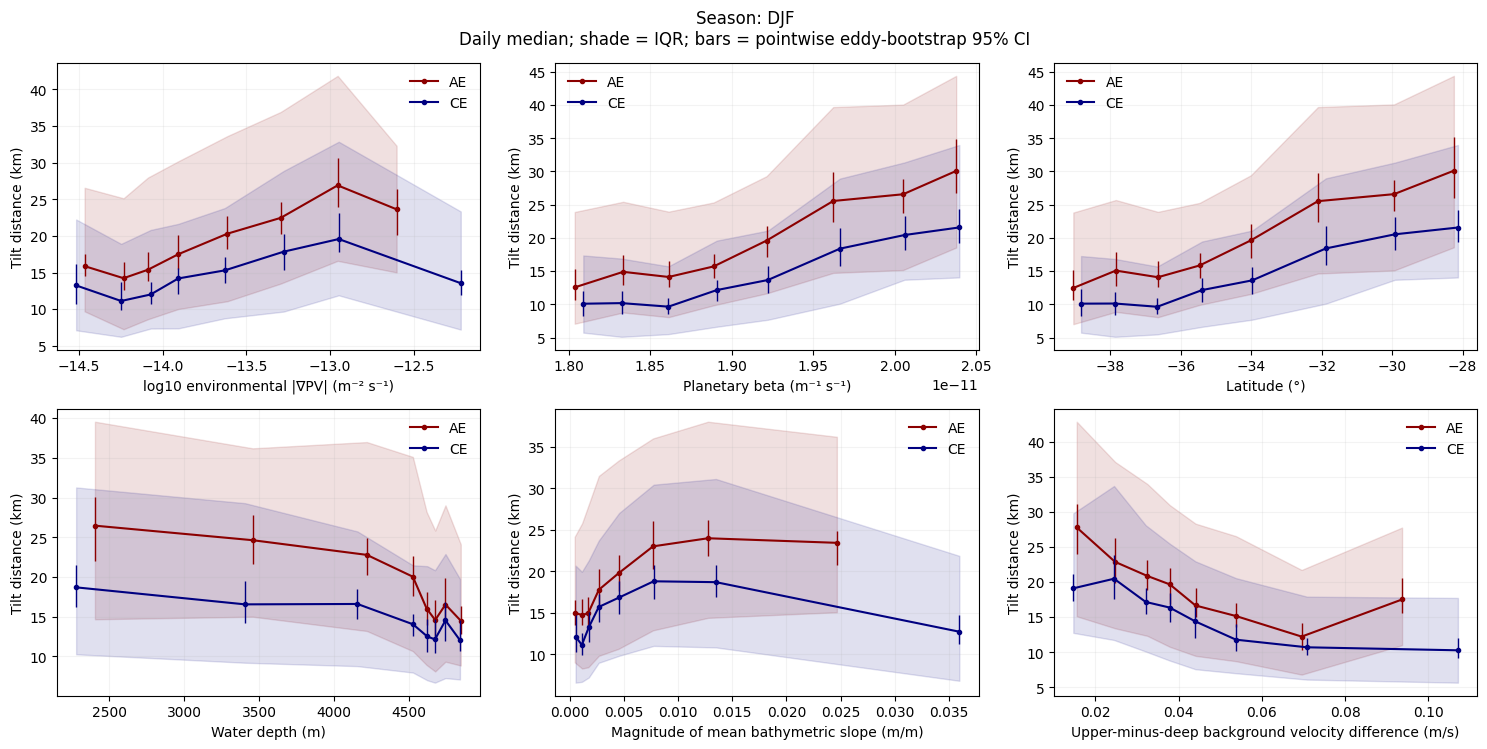

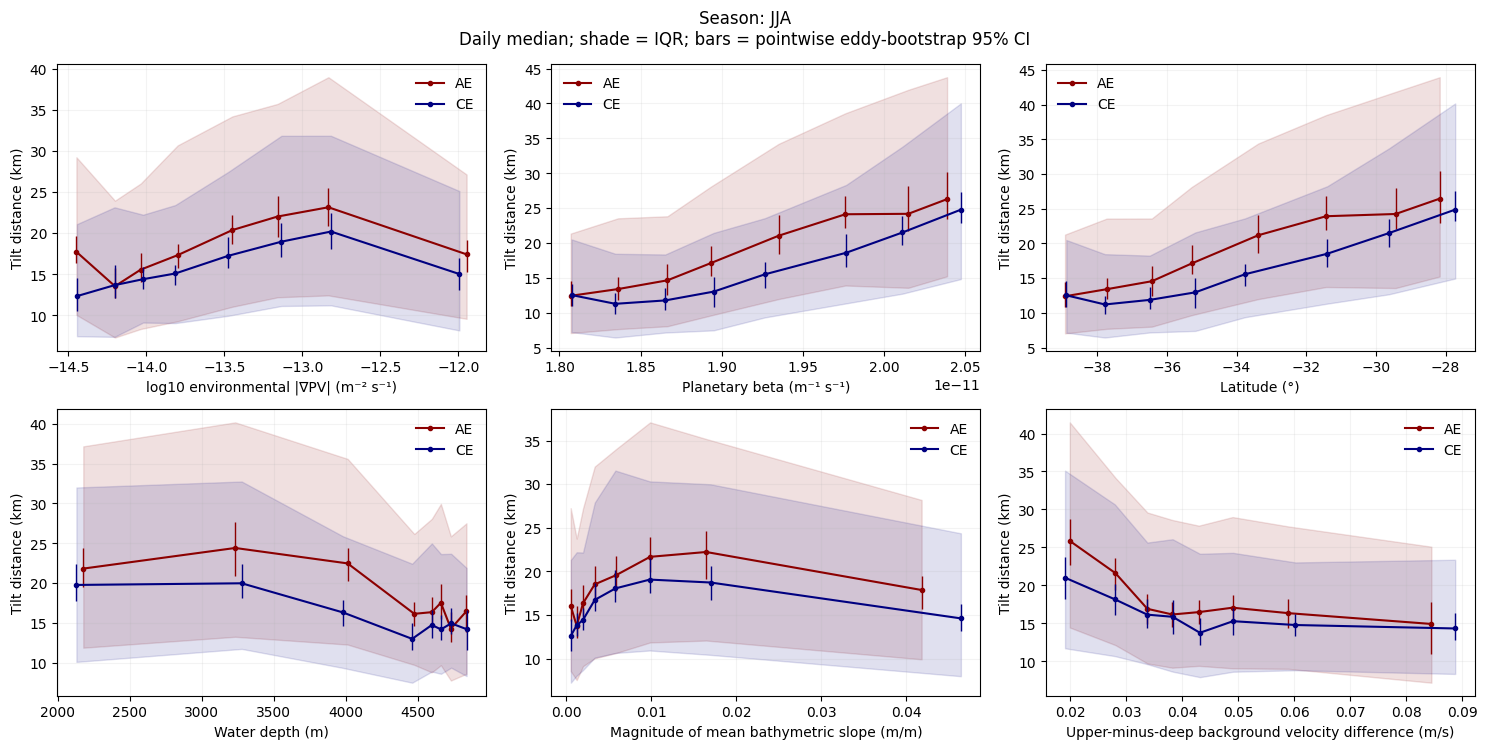

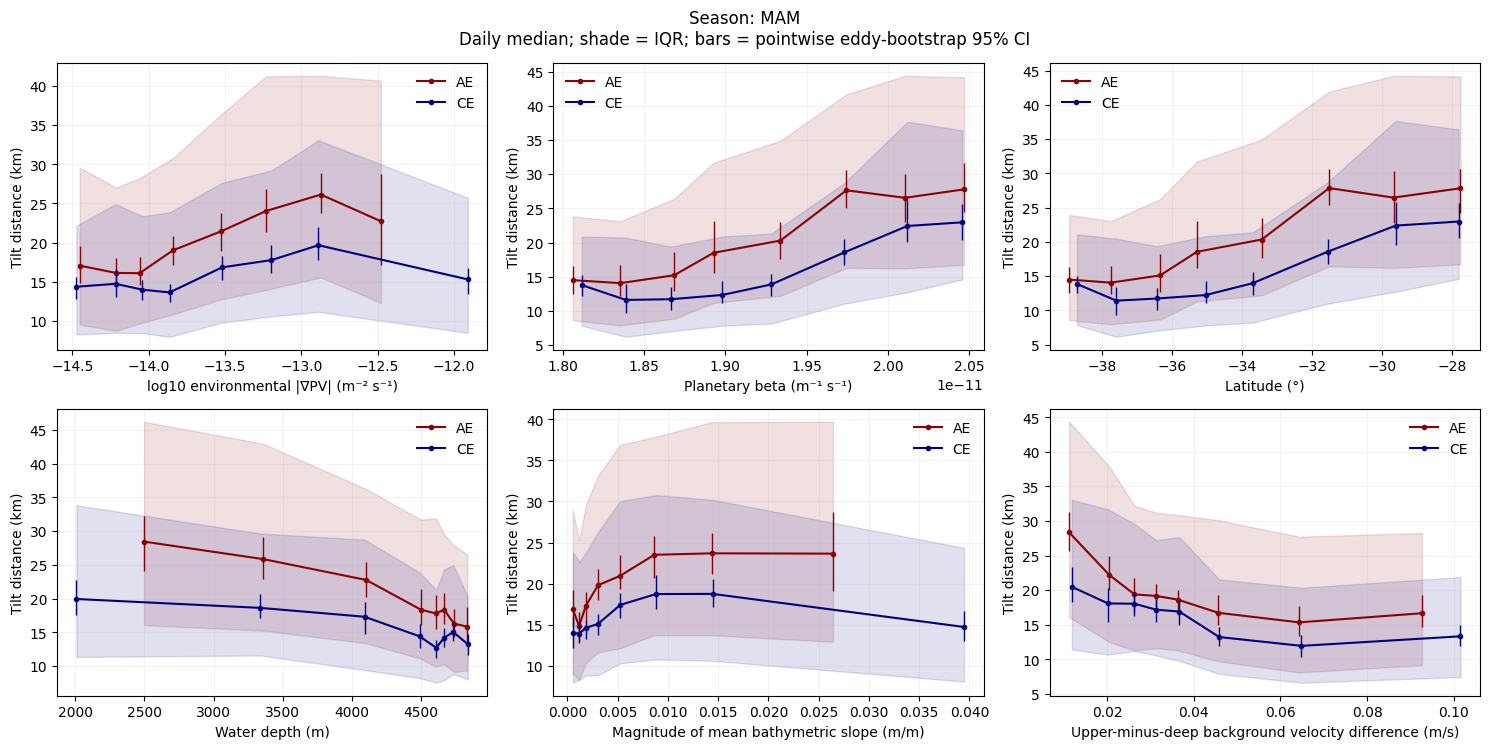

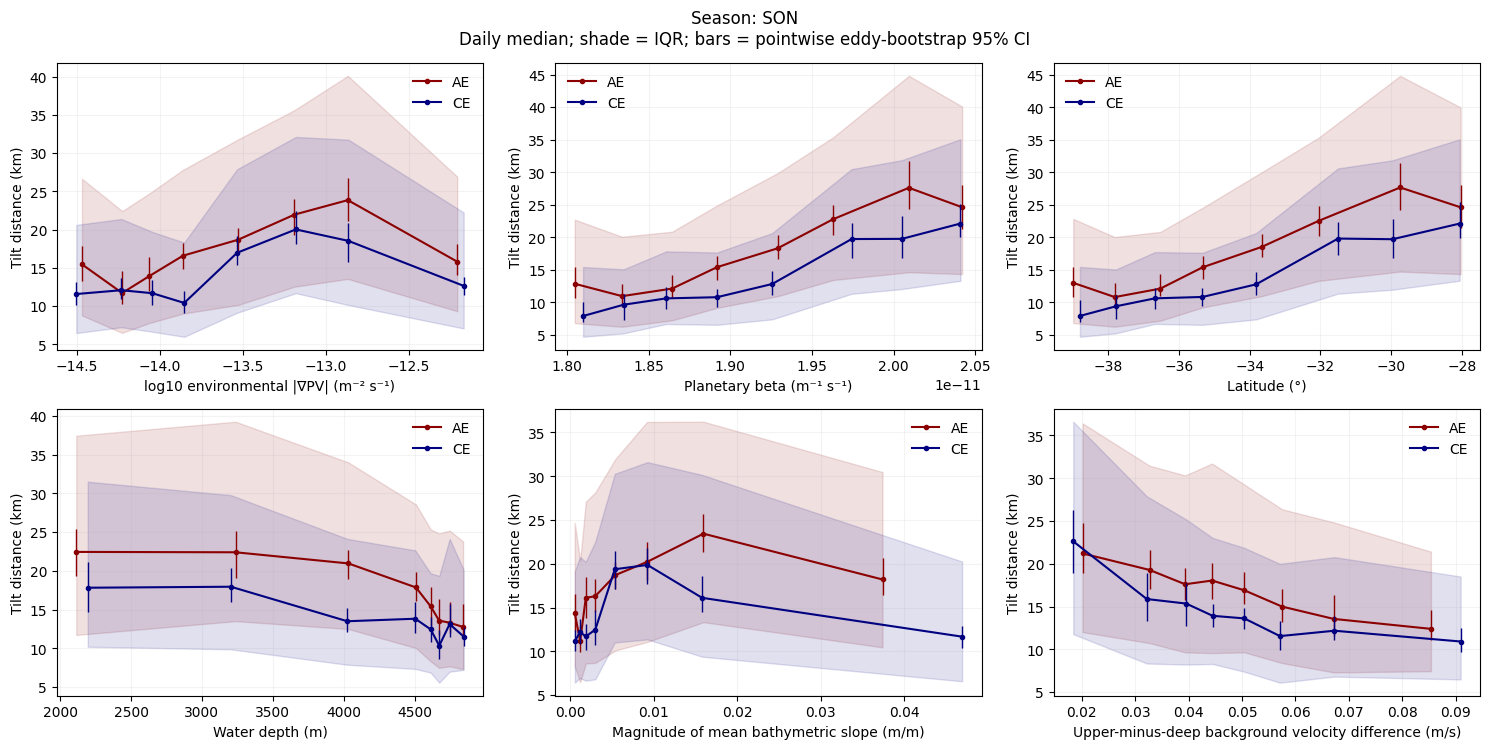

In [6]:
stratified_metrics=['log10_PV_grad_mag','beta','lat','h','slope']
if 'shear_mag_ms' in environment:stratified_metrics+=['shear_mag_ms']
for grouping in ['Region','Season']:
    if grouping not in environment:continue
    for label,part in environment.groupby(grouping,observed=True):
        key=f'{grouping}_{label}'
        results[key+'_availability']=ctl.audit(part,stratified_metrics)
        results[key+'_bins']=ctl.panels(part,stratified_metrics,n_boot=N_BOOT,min_eddies=MIN_EDDIES_PER_BIN,title=f'{grouping}: {label}')
        results[key+'_correlations']=ctl.correlations(part,stratified_metrics,n_boot=N_BOOT)

## Equal-eddy and adjusted comparisons
Each focal environmental predictor is fitted separately; correlated beta and latitude are not fitted together. Coefficients remain exploratory associations, including because the environmental topographic PV term itself depends on reconstructed eddy vorticity.

In [7]:
for outcome in ['TiltDis','tilt_over_radius']:
    results['eddy_equal_correlations_'+outcome]=ctl.correlations(environment,env_metrics,y=outcome,n_boot=N_BOOT)
    results['adjusted_'+outcome]=ctl.adjusted(environment,env_metrics,y=outcome)
    display(results['eddy_equal_correlations_'+outcome])
    display(results['adjusted_'+outcome])

,metric,Cyc,outcome,eddies,rho,ci_low,ci_high
0,log10_PV_grad_mag,AE,TiltDis,1416,0.208307,0.151014,0.254995
1,log10_PV_grad_mag,CE,TiltDis,1530,0.098046,0.048044,0.150431
2,log10_PV_grad_plan_mag,AE,TiltDis,1416,0.309752,0.268999,0.357299
3,log10_PV_grad_plan_mag,CE,TiltDis,1530,0.266448,0.217253,0.312561
4,log10_PV_grad_topo_mag,AE,TiltDis,1416,0.221599,0.176340,0.266050
5,log10_PV_grad_topo_mag,CE,TiltDis,1530,0.104307,0.053241,0.147919
6,log10_topo_plan_ratio,AE,TiltDis,1416,0.208988,0.159073,0.255910
7,log10_topo_plan_ratio,CE,TiltDis,1530,0.074419,0.025290,0.125508
8,PV_grad_coherence,AE,TiltDis,1416,-0.092385,-0.144688,-0.038140
9,PV_grad_coherence,CE,TiltDis,1530,-0.099191,-0.150291,-0.056305


,metric,Cyc,outcome,eddy_days,eddies,status,slope,ci_low,ci_high,p,controls,q_BH
0,log10_PV_grad_mag,AE,TiltDis,51167,1416,ok,0.039060,0.016494,0.061626,6.925640e-04,"Rc, vertical_extent_m, lat, Region, Season",1.978754e-03
1,log10_PV_grad_mag,CE,TiltDis,50489,1530,ok,0.002264,-0.024215,0.028744,8.668917e-01,"Rc, vertical_extent_m, lat, Region, Season",8.970239e-01
2,log10_PV_grad_plan_mag,AE,TiltDis,51167,1416,ok,0.002247,-0.018537,0.023031,8.321886e-01,"Rc, vertical_extent_m, lat, Region, Season",8.970239e-01
3,log10_PV_grad_plan_mag,CE,TiltDis,50489,1530,ok,0.033203,0.012597,0.053810,1.588126e-03,"Rc, vertical_extent_m, lat, Region, Season",3.529169e-03
4,log10_PV_grad_topo_mag,AE,TiltDis,51167,1416,ok,0.045595,0.021791,0.069399,1.739201e-04,"Rc, vertical_extent_m, lat, Region, Season",5.797337e-04
5,log10_PV_grad_topo_mag,CE,TiltDis,50489,1530,ok,-0.002245,-0.028848,0.024358,8.686144e-01,"Rc, vertical_extent_m, lat, Region, Season",8.970239e-01
6,log10_topo_plan_ratio,AE,TiltDis,51167,1416,ok,0.050134,0.026599,0.073668,2.977858e-05,"Rc, vertical_extent_m, lat, Region, Season",1.191143e-04
7,log10_topo_plan_ratio,CE,TiltDis,50489,1530,ok,-0.018118,-0.044251,0.008016,1.742118e-01,"Rc, vertical_extent_m, lat, Region, Season",2.635296e-01
8,PV_grad_coherence,AE,TiltDis,51167,1416,ok,0.014118,-0.006732,0.034968,1.844707e-01,"Rc, vertical_extent_m, lat, Region, Season",2.635296e-01
9,PV_grad_coherence,CE,TiltDis,50489,1530,ok,-0.004188,-0.025674,0.017297,7.024031e-01,"Rc, vertical_extent_m, lat, Region, Season",8.780039e-01


,metric,Cyc,outcome,eddies,rho,ci_low,ci_high
0,log10_PV_grad_mag,AE,tilt_over_radius,1416,0.275506,0.225908,0.322969
1,log10_PV_grad_mag,CE,tilt_over_radius,1530,0.184668,0.134270,0.234945
2,log10_PV_grad_plan_mag,AE,tilt_over_radius,1416,0.266476,0.222196,0.324179
3,log10_PV_grad_plan_mag,CE,tilt_over_radius,1530,0.222157,0.172441,0.269938
4,log10_PV_grad_topo_mag,AE,tilt_over_radius,1416,0.288935,0.238310,0.328168
5,log10_PV_grad_topo_mag,CE,tilt_over_radius,1530,0.191235,0.142800,0.233832
6,log10_topo_plan_ratio,AE,tilt_over_radius,1416,0.280647,0.239561,0.327801
7,log10_topo_plan_ratio,CE,tilt_over_radius,1530,0.172090,0.123568,0.216874
8,PV_grad_coherence,AE,tilt_over_radius,1416,0.214756,0.170743,0.264628
9,PV_grad_coherence,CE,tilt_over_radius,1530,0.220510,0.169891,0.267962


,metric,Cyc,outcome,eddy_days,eddies,status,slope,ci_low,ci_high,p,controls,q_BH
0,log10_PV_grad_mag,AE,tilt_over_radius,51167,1416,ok,0.011769,0.005466,0.018073,2.527460e-04,"Rc, vertical_extent_m, lat, Region, Season",5.054919e-04
1,log10_PV_grad_mag,CE,tilt_over_radius,50489,1530,ok,0.007912,0.000375,0.015450,3.964613e-02,"Rc, vertical_extent_m, lat, Region, Season",7.208387e-02
2,log10_PV_grad_plan_mag,AE,tilt_over_radius,51167,1416,ok,0.003437,-0.002769,0.009643,2.776939e-01,"Rc, vertical_extent_m, lat, Region, Season",3.340326e-01
3,log10_PV_grad_plan_mag,CE,tilt_over_radius,50489,1530,ok,0.013185,0.006738,0.019632,6.119786e-05,"Rc, vertical_extent_m, lat, Region, Season",1.529946e-04
4,log10_PV_grad_topo_mag,AE,tilt_over_radius,51167,1416,ok,0.013620,0.007142,0.020098,3.771765e-05,"Rc, vertical_extent_m, lat, Region, Season",1.077647e-04
5,log10_PV_grad_topo_mag,CE,tilt_over_radius,50489,1530,ok,0.007164,-0.000382,0.014709,6.277401e-02,"Rc, vertical_extent_m, lat, Region, Season",9.657540e-02
6,log10_topo_plan_ratio,AE,tilt_over_radius,51167,1416,ok,0.014201,0.007879,0.020522,1.067193e-05,"Rc, vertical_extent_m, lat, Region, Season",4.268774e-05
7,log10_topo_plan_ratio,CE,tilt_over_radius,50489,1530,ok,0.002677,-0.004419,0.009773,4.596401e-01,"Rc, vertical_extent_m, lat, Region, Season",4.838317e-01
8,PV_grad_coherence,AE,tilt_over_radius,51167,1416,ok,0.012689,0.006963,0.018414,1.401616e-05,"Rc, vertical_extent_m, lat, Region, Season",4.672055e-05
9,PV_grad_coherence,CE,tilt_over_radius,50489,1530,ok,0.002190,-0.002996,0.007375,4.078904e-01,"Rc, vertical_extent_m, lat, Region, Season",4.532115e-01


## Export tables and settings

In [8]:
NOTEBOOK_NAME='environment'

if SAVE_RESULTS:
    settings=dict(n_boot=N_BOOT,min_eddies_per_bin=MIN_EDDIES_PER_BIN,max_depth_m=MAX_DEPTH_M,
                  target_depths=TARGET_DEPTHS,depth_tolerance_m=DEPTH_TOLERANCE_M,
                  n2_min_coverage=MIN_N2_COVERAGE,vv_fraction=VV_FRACTION,
                  vv_min_cells=MIN_VV_CELLS,vv_min_coverage=MIN_VV_COVERAGE,
                  unavailable_sections=[str(p) for p in inputs if not Path(p).exists()])
    saved=ctl.save_results(OUTPUT_ROOT/NOTEBOOK_NAME,results,settings,inputs)
    print('Saved tables and provenance to',saved)

Saved tables and provenance to /srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset_modular/eddy_env_tilt_controls/environment/20260925T031630175756Z
